# NLDisco SED place-cell analysis

This notebook trains NLDisco's sparse encoder-decoder (SED) on the committed synthetic
place-cell dataset, evaluates reconstruction quality, constructs dense latent time courses,
maps latent activity over position, and compares linear position decoding from SED latents,
PCA components, and raw neural activity.

Set NLDISCO_NOTEBOOK_FAST=1 before execution for a short smoke test. The default runs the
full 60,000-bin dataset. Set NLDISCO_NOTEBOOK_SAVE=1 to overwrite the committed ratemap
metrics CSV with results from the current run.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch as t
from einops import asnumpy
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from nldisco import train as nt

SEED = 0
np.random.seed(SEED)
t.manual_seed(SEED)

FAST_RUN = os.getenv("NLDISCO_NOTEBOOK_FAST", "0") == "1"
SAVE_ARTIFACTS = os.getenv("NLDISCO_NOTEBOOK_SAVE", "0") == "1"

project_candidates = (Path.cwd(), Path.cwd().parent)
PROJECT_ROOT = next(
    candidate for candidate in project_candidates
    if (candidate / "pyproject.toml").exists()
)
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
DATA_DIR = NOTEBOOK_DIR / "20Hz_50PCs_5Hz_50noise"
RESULTS_DIR = NOTEBOOK_DIR / "feature_ratemaps"

device = t.device("cuda" if t.cuda.is_available() else "cpu")
model_dtype = t.bfloat16 if device.type == "cuda" else t.float32
print(f"{PROJECT_ROOT=}")
print(f"{FAST_RUN=}, {SAVE_ARTIFACTS=}, {device=}, {model_dtype=}")

PROJECT_ROOT=PosixPath('/nfs/nhome/live/jbhagat/nldisco-paper-consolidation')
FAST_RUN=True, SAVE_ARTIFACTS=False, device=device(type='cuda'), model_dtype=torch.bfloat16


## Load and validate the synthetic dataset

In [2]:
spike_matrix = np.load(DATA_DIR / "spike_matrix.npy").T.astype(np.float32)
positions = np.load(DATA_DIR / "positions.npy").astype(np.float32)
timestamps = np.load(DATA_DIR / "timestamps.npy").astype(np.float32)

assert spike_matrix.ndim == 2
assert positions.ndim == timestamps.ndim == 1
assert spike_matrix.shape[0] == positions.size == timestamps.size
assert np.all(np.diff(timestamps) > 0)
assert np.isfinite(spike_matrix).all()
assert np.isfinite(positions).all()

n_examples = min(4096, len(positions)) if FAST_RUN else len(positions)
spike_matrix = spike_matrix[:n_examples]
positions = positions[:n_examples]
timestamps = timestamps[:n_examples]

print(f"spike counts: {spike_matrix.shape}")
print(f"positions: {positions.shape}, range=({positions.min():.3f}, {positions.max():.3f})")
print(f"duration: {timestamps[-1] - timestamps[0]:.1f} s")

spike counts: (4096, 51)
positions: (4096,), range=(0.000, 1.000)
duration: 20.5 s


## Train and evaluate an NLDisco SED

In [3]:
spike_cts = t.as_tensor(spike_matrix, dtype=model_dtype, device=device)

dsed_topk_map = {128: 2}
dsed_loss_x_map = {128: 1.0}
n_instances = 2

sed_cfg = nt.SedConfig(
    n_input=spike_cts.shape[1],
    dsed_topk_map=dsed_topk_map,
    dsed_loss_x_map=dsed_loss_x_map,
    seq_len=1,
    n_instances=n_instances,
    dtype=model_dtype,
)
sed = nt.Sed(sed_cfg).to(device)

batch_size = min(256 if FAST_RUN else 1024, n_examples)
n_epochs = 1 if FAST_RUN else 20
steps_per_epoch = max(1, n_examples // batch_size)
n_steps = max(10, steps_per_epoch * n_epochs)

training_log = nt.optimize(
    spk_cts=spike_cts,
    sed=sed,
    loss_fn=nt.mse,
    optimizer=t.optim.Adam(sed.parameters(), lr=5e-3),
    use_lr_sched=True,
    dead_neuron_window=max(1, steps_per_epoch // 3),
    n_steps=n_steps,
    log_freq=max(1, n_steps // 10),
    batch_sz=batch_size,
    log_wandb=False,
    plot_l0=False,
)

assert not sed.W_enc.isnan().any()
assert not sed.W_dec.isnan().any()
print(f"trained for {n_steps} steps; final loss={training_log['loss'][max(training_log['loss'])]:.6f}")

SED batch training step:   0%|          | 0/16 [00:00<?, ?it/s]

SED batch training step:   0%|          | 0/16 [00:00<?, ?it/s, loss=0.03188,  l0_mean=2.0, l0_std=3.3369193077087402, frac_dead=0.0]

SED batch training step:   6%|▋         | 1/16 [00:00<00:09,  1.55it/s, loss=0.03188,  l0_mean=2.0, l0_std=3.3369193077087402, frac_dead=0.0]

SED batch training step:   6%|▋         | 1/16 [00:00<00:09,  1.55it/s, loss=0.02986,  l0_mean=2.0, l0_std=3.300358772277832, frac_dead=0.0] 

SED batch training step:   6%|▋         | 1/16 [00:00<00:09,  1.55it/s, loss=0.02743,  l0_mean=2.0, l0_std=3.5367791652679443, frac_dead=0.0]

...

SED batch training step:   6%|▋         | 1/16 [00:00<00:09,  1.55it/s, loss=0.02613,  l0_mean=2.0, l0_std=4.790319442749023, frac_dead=0.16015625]

SED batch training step:   6%|▋         | 1/16 [00:00<00:09,  1.55it/s, loss=0.02485,  l0_mean=2.0, l0_std=4.745582103729248, frac_dead=0.171875]  

SED batch training step:   6%|▋         | 1/16 [00:00<00:09,  1.55it/s, loss=0.02636,  l0_mean=2.0, l0_std=4.839902877807617, frac_dead=0.1640625]

SED batch training step: 100%|██████████| 16/16 [00:00<00:00, 21.58it/s, loss=0.02636,  l0_mean=2.0, l0_std=4.839902877807617, frac_dead=0.1640625]

trained for 16 steps; final loss=0.026359


SED batch evaluation step:   0%|          | 0/16 [00:00<?, ?it/s]

SED batch evaluation step: 100%|██████████| 16/16 [00:00<00:00, 595.74it/s]

evaluated 4,096 time bins
mean unit R²: 0.182


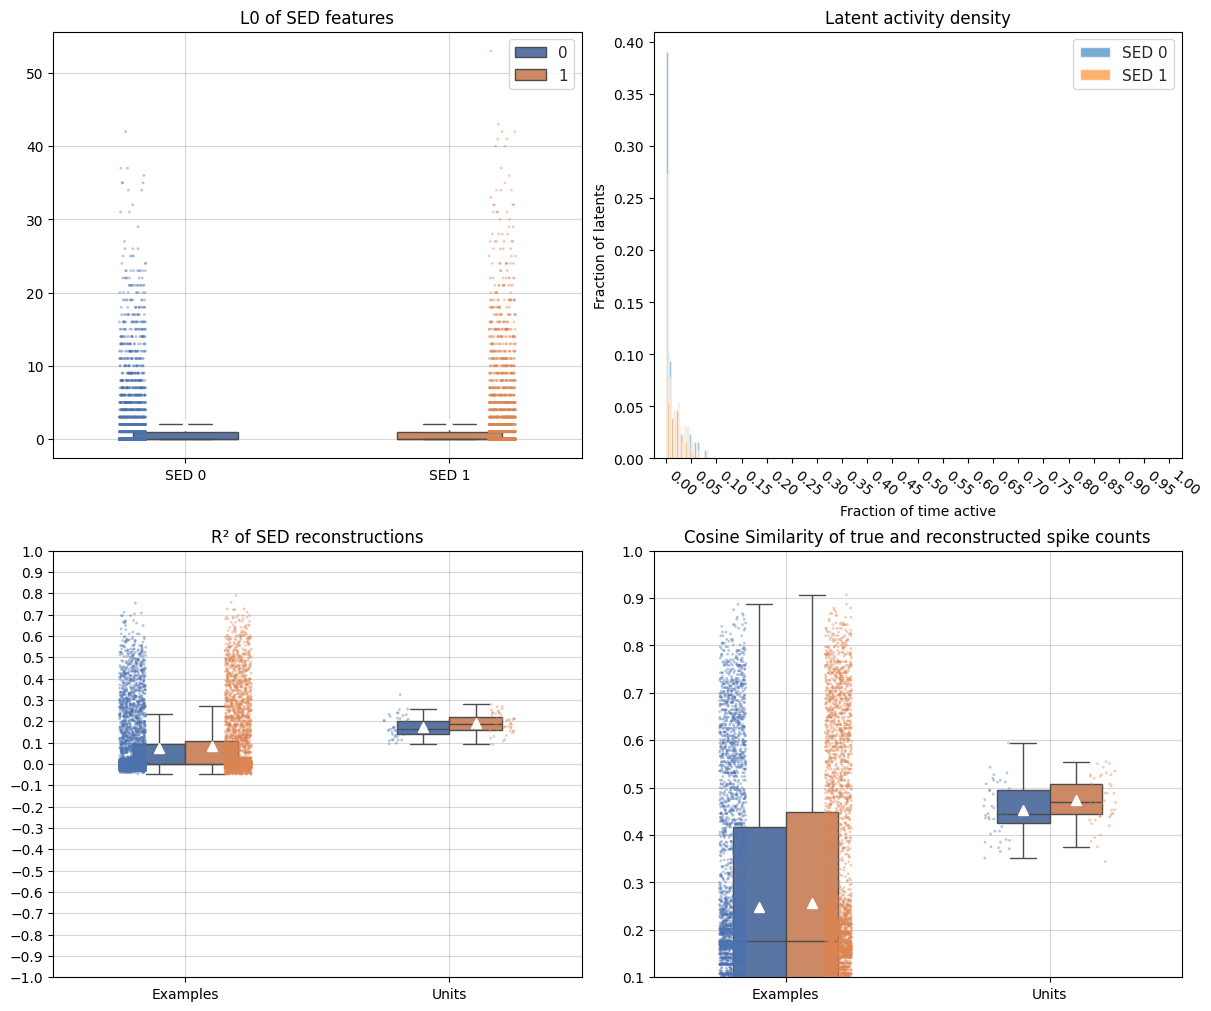

In [4]:
(
    evaluation_figure,
    topk_acts_4d,
    recon_spk_cts,
    r2_per_unit,
    r2_per_example,
    cosine_similarity_per_unit,
    cosine_similarity_per_example,
) = nt.eval_model(spike_cts, sed, batch_sz=batch_size)

n_reconstructed = recon_spk_cts.shape[0]
assert n_reconstructed > 0
assert topk_acts_4d.shape[1] == 4
print(f"evaluated {n_reconstructed:,} time bins")
print(f"mean unit R²: {np.nanmean(r2_per_unit):.3f}")

## Construct latent time courses

eval_model returns sparse activation rows in
(example_idx, instance_idx, latent_idx, activation_value) order. This cell converts them
to a dense array for spatial tuning and decoding analyses.

In [5]:
activation_rows = asnumpy(topk_acts_4d)
acts_df = pd.DataFrame(
    activation_rows,
    columns=["example_idx", "instance_idx", "latent_idx", "activation_value"],
)
acts_df[["example_idx", "instance_idx", "latent_idx"]] = (
    acts_df[["example_idx", "instance_idx", "latent_idx"]].astype(int)
)

n_latents = max(dsed_topk_map)
latent_acts = np.zeros(
    (n_reconstructed, n_instances, n_latents),
    dtype=np.float32,
)
latent_acts[
    acts_df["example_idx"].to_numpy(),
    acts_df["instance_idx"].to_numpy(),
    acts_df["latent_idx"].to_numpy(),
] = acts_df["activation_value"].to_numpy(dtype=np.float32)

assert np.count_nonzero(latent_acts) == len(acts_df)
display(acts_df.head())

,example_idx,instance_idx,latent_idx,activation_value
0,6,1,126,0.147461
1,27,1,83,0.147461
2,27,1,125,0.155273
3,43,1,126,0.147461
4,47,0,54,0.148438


## Map SED latents over position

,latent_idx,peak_bin,peak_value,mean_value,selectivity,activation_fraction
40,40,4,0.001118,0.000056,20.000000,0.000244
19,19,1,0.001049,0.000052,20.000000,0.000244
35,35,5,0.000956,0.000048,20.000000,0.000244
79,79,5,0.000947,0.000047,20.000000,0.000244
63,63,7,0.000886,0.000044,20.000000,0.000244
60,60,1,0.000859,0.000043,20.000000,0.000244
84,84,16,0.000847,0.000042,20.000000,0.000244
56,56,6,0.000788,0.000039,19.999999,0.000244
37,37,9,0.001271,0.000101,12.578241,0.000488
102,102,9,0.001012,0.000091,11.105921,0.000488


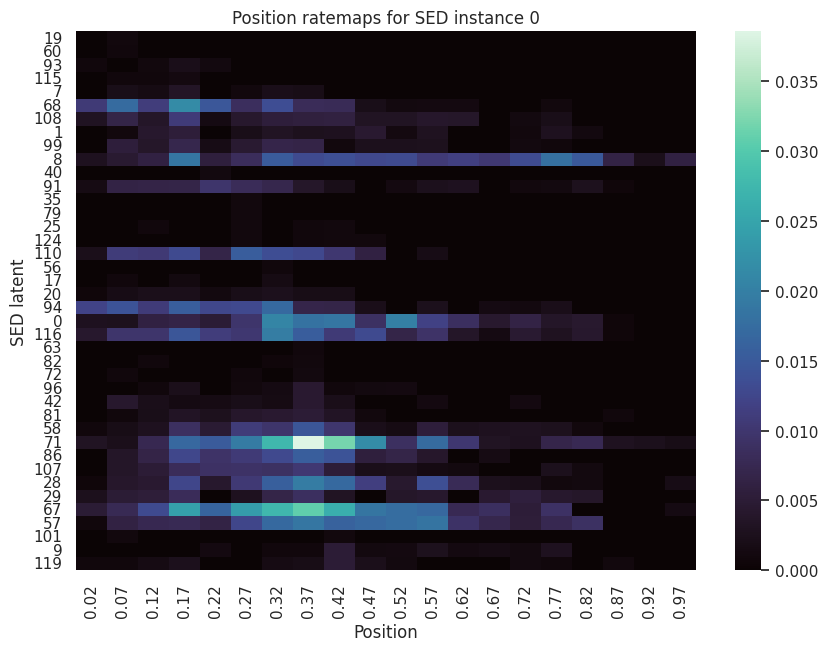

In [6]:
def compute_ratemaps(
    activations: np.ndarray,
    position: np.ndarray,
    n_bins: int = 20,
) -> tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    edges = np.linspace(position.min(), position.max(), n_bins + 1)
    bin_index = np.clip(np.digitize(position, edges) - 1, 0, n_bins - 1)
    occupancy = np.bincount(bin_index, minlength=n_bins).astype(np.float64)
    occupancy[occupancy == 0] = np.nan

    ratemaps = np.empty((activations.shape[1], n_bins), dtype=np.float64)
    rows = []
    for latent_idx in range(activations.shape[1]):
        activity = activations[:, latent_idx]
        activity_by_bin = np.bincount(
            bin_index,
            weights=activity,
            minlength=n_bins,
        )
        ratemap = activity_by_bin / occupancy
        ratemaps[latent_idx] = ratemap
        finite = ratemap[np.isfinite(ratemap)]
        mean_value = finite.mean() if finite.size else 0.0
        peak_bin = int(np.nanargmax(ratemap)) if finite.size else -1
        peak_value = float(np.nanmax(ratemap)) if finite.size else 0.0
        rows.append(
            {
                "latent_idx": latent_idx,
                "peak_bin": peak_bin,
                "peak_value": peak_value,
                "mean_value": mean_value,
                "selectivity": peak_value / (mean_value + 1e-12),
                "activation_fraction": float(np.count_nonzero(activity) / len(activity)),
            }
        )

    centers = (edges[:-1] + edges[1:]) / 2
    return ratemaps, pd.DataFrame(rows), centers


instance_idx = 0
ratemaps, ratemap_metrics, position_centers = compute_ratemaps(
    latent_acts[:, instance_idx],
    positions[:n_reconstructed],
)

active_metrics = ratemap_metrics.query("activation_fraction > 0").copy()
display(active_metrics.sort_values("selectivity", ascending=False).head(10))

ordered_latents = (
    active_metrics.sort_values(["peak_bin", "selectivity"], ascending=[True, False])
    .head(40)["latent_idx"]
    .to_numpy()
)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    ratemaps[ordered_latents],
    cmap="mako",
    xticklabels=np.round(position_centers, 2),
    yticklabels=ordered_latents,
    ax=ax,
)
ax.set_xlabel("Position")
ax.set_ylabel("SED latent")
ax.set_title(f"Position ratemaps for SED instance {instance_idx}")
plt.show()

if SAVE_ARTIFACTS:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    ratemap_metrics.to_csv(RESULTS_DIR / "feature_ratemap_metrics.csv", index=False)
    print(f"saved {RESULTS_DIR / 'feature_ratemap_metrics.csv'}")

## Decode position from learned and baseline representations

The comparison uses the same shuffled K-fold splits for SED latents, PCA components, and
raw spike counts. Scaling and ridge regression are fit within each training fold.

,representation,k,r2,r2_std,rmse
0,SED,1,-0.000486,0.000384,0.263938
1,PCA,1,0.229662,0.009991,0.231595
2,SED,2,0.002607,0.001532,0.263531
3,PCA,2,0.237384,0.009414,0.230434
4,SED,5,0.034905,0.005586,0.259231
5,PCA,5,0.245517,0.009442,0.229203
6,SED,10,0.050892,0.002372,0.257073
7,PCA,10,0.256424,0.012303,0.227538
8,SED,20,0.055032,0.003868,0.256513
9,PCA,20,0.268778,0.012280,0.225638


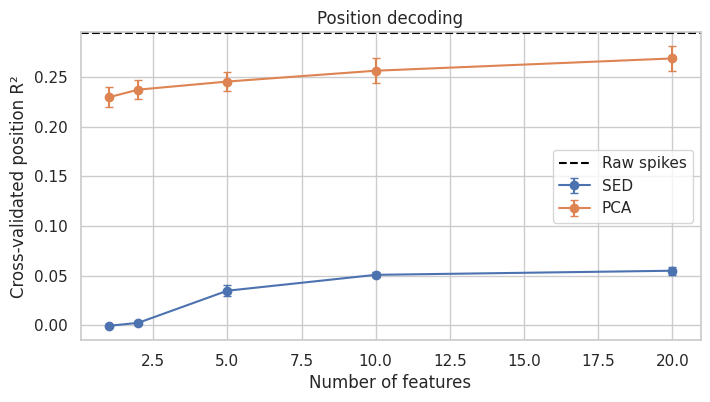

In [7]:
def cross_validated_position_score(
    features: np.ndarray,
    target: np.ndarray,
    *,
    n_splits: int,
) -> tuple[float, float, float]:
    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    r2_values = []
    rmse_values = []
    for train_index, test_index in splitter.split(features):
        model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
        model.fit(features[train_index], target[train_index])
        prediction = model.predict(features[test_index])
        r2_values.append(r2_score(target[test_index], prediction))
        rmse_values.append(
            np.sqrt(mean_squared_error(target[test_index], prediction))
        )
    return (
        float(np.mean(r2_values)),
        float(np.std(r2_values)),
        float(np.mean(rmse_values)),
    )


target = positions[:n_reconstructed]
sed_features = latent_acts[:, instance_idx]
feature_order = np.argsort(sed_features.var(axis=0))[::-1]
pca_components = PCA(
    n_components=min(20, spike_matrix.shape[1]),
    random_state=SEED,
).fit_transform(spike_matrix[:n_reconstructed])

candidate_k = (1, 2, 5, 10, 20)
n_splits = 3 if FAST_RUN else 5
decoding_rows = []

for k in candidate_k:
    if k <= sed_features.shape[1]:
        mean_r2, std_r2, mean_rmse = cross_validated_position_score(
            sed_features[:, feature_order[:k]],
            target,
            n_splits=n_splits,
        )
        decoding_rows.append(
            {"representation": "SED", "k": k, "r2": mean_r2, "r2_std": std_r2, "rmse": mean_rmse}
        )

    if k <= pca_components.shape[1]:
        mean_r2, std_r2, mean_rmse = cross_validated_position_score(
            pca_components[:, :k],
            target,
            n_splits=n_splits,
        )
        decoding_rows.append(
            {"representation": "PCA", "k": k, "r2": mean_r2, "r2_std": std_r2, "rmse": mean_rmse}
        )

raw_r2, raw_r2_std, raw_rmse = cross_validated_position_score(
    spike_matrix[:n_reconstructed],
    target,
    n_splits=n_splits,
)
decoding_rows.append(
    {
        "representation": "Raw spikes",
        "k": spike_matrix.shape[1],
        "r2": raw_r2,
        "r2_std": raw_r2_std,
        "rmse": raw_rmse,
    }
)

decoding_results = pd.DataFrame(decoding_rows)
display(decoding_results)

fig, ax = plt.subplots(figsize=(8, 4))
for representation in ("SED", "PCA"):
    subset = decoding_results.query("representation == @representation")
    ax.errorbar(
        subset["k"],
        subset["r2"],
        yerr=subset["r2_std"],
        marker="o",
        capsize=3,
        label=representation,
    )
ax.axhline(raw_r2, color="black", linestyle="--", label="Raw spikes")
ax.set_xlabel("Number of features")
ax.set_ylabel("Cross-validated position R²")
ax.set_title("Position decoding")
ax.legend()
plt.show()

## Reproducibility checks

A successful run reaches this cell with finite model weights, non-empty sparse latent
activations, spatial tuning metrics, and cross-validated decoding results.

In [8]:
assert len(acts_df) > 0
assert np.isfinite(ratemap_metrics[["peak_value", "mean_value", "selectivity"]]).all().all()
assert np.isfinite(decoding_results[["r2", "r2_std", "rmse"]]).all().all()
print("Notebook completed successfully.")

Notebook completed successfully.
